<a href="https://colab.research.google.com/github/hsy0ung/data-analyze/blob/main/4_%EB%B6%84%EC%84%9D%EC%8B%A4%EC%8A%B5_3%ED%8C%80_%ED%98%84%EC%86%8C%EC%98%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 음주 여부에 따른 간 지표 차이의 통계적 유의성

### 라이브러리 불러오기

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 데이터 불러오기

In [ ]:
health_path = '/content/drive/MyDrive/코드잇 _데이터분석_14기/00_etc/mission/미션4/data/health_info_중급자용.csv'
health_df = pd.read_csv(health_path)

### 서론

간 질환은 초기 증상이 거의 없어 조기에 발견되기 어려운 질환 중 하나이며, 국내에서 주요 건강 문제로 인식되고 있다. 특히 **음주** 습관은 간 기능 저하와 밀접한 연관이 있는 대표적인 생활습관 요인으로 알려져 있다. 과도한 음주는 간 세포 손상을 유발하고 회복을 지연시켜 간 건강 악화와 관련될 수 있다.

증상이 거의 없어 발견되기 어려운 간 질환은 건강검진에서 측정되는 혈액 검사 수치를 통해 간접적으로 평가할 수 있다. 그중 **혈청지오티(AST), 혈청지피티(ALT), 감마지피티(GGT)**는, 간세포 손상이나 기능 이상을 반영하는 대표적인 간 기능 지표로 질환 초기 단계에서 이상을 발견하는 데 중요한 역할을 한다. 특히 GGT는 음주와 관련성이 높은 지표로 알려져 있다.

본 연구에서는 **건강검진 데이터**를 이용해 음주 여부에 따른 간 기능 지표(AST, ALT, GGT)의 차이를 분석하고, 음주가 간 건강에 미치는 영향을 탐색하고자 한다.

| 지표 | 의미 | 정상 범위 |
| --  | --  |   --    |
|**혈청지오티(AST)**| 간세포 손상 지표(간 외 기타 장기 영향 O) | 40U/L 이하 |
| **혈청지피티(ALT)** | 간에 집중적으로 분포, 간 질환 및 손상을 판단 | 35~40U/L 이하 |
| **감마지피티(GGT)** | 간 세포막에 존재하는 효소, 알코올 섭취에 민감. |  남성: 11\~63U/L 이하 <br/> <br/> 여성: 8\~35U/L 이하 |

### 데이터 전처리

상술하였듯 본 연구에서는 건강검진 데이터를 사용하였으며,
**분석 대상 변수**는 음주 여부를 **독립변수**로, 간 기능 지표를 **종속변수**로 설정하였다.
또한 간 수치에 영향을 줄 수 있는 요인을 고려해 성별, 연령, BMI, 흡연여부를 **보조 변수**로 사용하였다.

In [ ]:
health = health_df.copy()

In [ ]:
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106876 entries, 0 to 106875
Data columns (total 30 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   기준년도         106876 non-null  int64  
 1   가입자일련번호      106876 non-null  int64  
 2   시도코드         106876 non-null  int64  
 3   성별           106876 non-null  int64  
 4   연령대코드(5세단위)  106876 non-null  int64  
 5   신장(5cm단위)    106876 non-null  int64  
 6   체중(5kg단위)    106876 non-null  int64  
 7   허리둘레         106876 non-null  float64
 8   시력(좌)        106876 non-null  float64
 9   시력(우)        106876 non-null  float64
 10  청력(좌)        106876 non-null  float64
 11  청력(우)        106876 non-null  float64
 12  수축기혈압        106876 non-null  float64
 13  이완기혈압        106876 non-null  float64
 14  식전혈당(공복혈당)   106876 non-null  float64
 15  총콜레스테롤       106876 non-null  float64
 16  트리글리세라이드     106876 non-null  float64
 17  HDL콜레스테롤     106876 non-null  float64
 18  LDL콜레스테롤     106876 non-

분석에 필요한 변수만 추출한 후, 가독성을 높이기 위해 변수명을 영어로 변경하였다.

In [ ]:
health = health[['성별', '연령대코드(5세단위)', '신장(5cm단위)', '체중(5kg단위)', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피', '흡연상태', '음주여부']]

In [ ]:
health = health.rename(
    columns={
        '성별': 'sex',
        '연령대코드(5세단위)': 'age_group',
        '신장(5cm단위)': 'height',
        '체중(5kg단위)': 'weight',
        '혈청지오티(AST)': 'AST',
        '혈청지피티(ALT)':'ALT',
        '감마지티피': 'GGT',
        '흡연상태': 'smoke',
        '음주여부': 'drink'
        })

또한 체질량지수(BMI)는 신장과 체중 데이터를 이용하여 계산하였으며, <br/> **BMI = 체중(kg) / 신장(m)$^2$** 공식을 이용하였다.

In [ ]:
height_m = health['height'] / 100

health['bmi'] = round(health['weight'] / height_m ** 2, 2)

In [ ]:
health

,sex,age_group,height,weight,AST,ALT,GGT,smoke,drink,bmi
0,1,13,165,60,22.0,17.0,34.0,2.0,1.0,22.04
1,1,15,175,75,22.0,16.0,31.0,2.0,1.0,24.49
2,1,7,170,70,22.0,32.0,30.0,1.0,1.0,24.22
3,2,14,155,50,22.0,19.0,13.0,1.0,0.0,20.81
4,1,13,170,55,22.0,13.0,17.0,1.0,1.0,19.03
...,...,...,...,...,...,...,...,...,...,...
106871,1,8,180,85,43.0,34.0,13.0,1.0,1.0,26.23
106872,2,14,150,70,48.0,49.0,17.0,1.0,0.0,31.11
106873,1,14,165,105,79.0,55.0,99.0,2.0,1.0,38.57
106874,1,6,170,90,95.0,251.0,77.0,1.0,1.0,31.14


BMI 계산 이후 신장과 체중 변수는 분석에 직접 사용되지 않으므로 제외하였다.

In [ ]:
health.drop(columns=['height', 'weight'], inplace=True)

In [ ]:
health

,sex,age_group,AST,ALT,GGT,smoke,drink,bmi
0,1,13,22.0,17.0,34.0,2.0,1.0,22.04
1,1,15,22.0,16.0,31.0,2.0,1.0,24.49
2,1,7,22.0,32.0,30.0,1.0,1.0,24.22
3,2,14,22.0,19.0,13.0,1.0,0.0,20.81
4,1,13,22.0,13.0,17.0,1.0,1.0,19.03
...,...,...,...,...,...,...,...,...
106871,1,8,43.0,34.0,13.0,1.0,1.0,26.23
106872,2,14,48.0,49.0,17.0,1.0,0.0,31.11
106873,1,14,79.0,55.0,99.0,2.0,1.0,38.57
106874,1,6,95.0,251.0,77.0,1.0,1.0,31.14


또한, 성별, 음주여부, 흡연상태는 범주형 변수로 변경하여 해석에 용이하도록 처리하였다.

In [ ]:
health['sex'] = health['sex'].map({1: 'male', 2: 'female'})

In [ ]:
health

,sex,age_group,AST,ALT,GGT,smoke,drink,bmi
0,male,13,22.0,17.0,34.0,2.0,1.0,22.04
1,male,15,22.0,16.0,31.0,2.0,1.0,24.49
2,male,7,22.0,32.0,30.0,1.0,1.0,24.22
3,female,14,22.0,19.0,13.0,1.0,0.0,20.81
4,male,13,22.0,13.0,17.0,1.0,1.0,19.03
...,...,...,...,...,...,...,...,...
106871,male,8,43.0,34.0,13.0,1.0,1.0,26.23
106872,female,14,48.0,49.0,17.0,1.0,0.0,31.11
106873,male,14,79.0,55.0,99.0,2.0,1.0,38.57
106874,male,6,95.0,251.0,77.0,1.0,1.0,31.14


In [ ]:
health['smoke'].unique()

array([2., 1., 3.])

In [ ]:
health['smoke'] = health['smoke'].astype('int')

In [ ]:
health['smoke']

,smoke
0,2
1,2
2,1
3,1
4,1
...,...
106871,1
106872,1
106873,2
106874,1


In [ ]:
health['smoke'] = health['smoke'].map({
    1: 'never',
    2: 'former',
    3: 'current'
})

In [ ]:
health['smoke'].head(3)

,smoke
0,former
1,former
2,never


In [ ]:
health['drink'].unique()

array([1., 0.])

In [ ]:
health['drink'] = health['drink'].astype('int')

In [ ]:
health['drink']

,drink
0,1
1,1
2,1
3,0
4,1
...,...
106871,1
106872,0
106873,1
106874,1


In [ ]:
health['drink'] = health['drink'].map({
    0: 'no',
    1: 'yes'
})

In [ ]:
health['drink'].head()

,drink
0,yes
1,yes
2,yes
3,no
4,yes


In [ ]:
health

,sex,age_group,AST,ALT,GGT,smoke,drink,bmi
0,male,13,22.0,17.0,34.0,former,yes,22.04
1,male,15,22.0,16.0,31.0,former,yes,24.49
2,male,7,22.0,32.0,30.0,never,yes,24.22
3,female,14,22.0,19.0,13.0,never,no,20.81
4,male,13,22.0,13.0,17.0,never,yes,19.03
...,...,...,...,...,...,...,...,...
106871,male,8,43.0,34.0,13.0,never,yes,26.23
106872,female,14,48.0,49.0,17.0,never,no,31.11
106873,male,14,79.0,55.0,99.0,former,yes,38.57
106874,male,6,95.0,251.0,77.0,never,yes,31.14


### 음주군과 비음주군의 간 수치 비교

In [ ]:
from scipy.stats import ttest_ind

yes = health[health['drink'] == 'yes']['AST']
no = health[health['drink'] == 'no']['AST']

ttest_ind(yes, no)

TtestResult(statistic=np.float64(5.963722851699414), pvalue=np.float64(2.473259288719509e-09), df=np.float64(106874.0))

In [ ]:
yes = health[health['drink'] == 'yes']['ALT']
no = health[health['drink'] == 'no']['ALT']

ttest_ind(yes, no)

TtestResult(statistic=np.float64(17.47344857299601), pvalue=np.float64(2.8417896643977853e-68), df=np.float64(106874.0))

In [ ]:
yes = health[health['drink'] == 'yes']['GGT']
no = health[health['drink'] == 'no']['GGT']

ttest_ind(yes, no)

TtestResult(statistic=np.float64(42.921744616485704), pvalue=np.float64(0.0), df=np.float64(106874.0))

독립표본의 t-검정 결과, 음주군과 비음주군 간 AST, ALT, GGT 모두에게서 통계적으로 유의미한 차이가 나타났다(p < 0.001). 특히 GGT에서 가장 큰 차이가 관찰되었다.

GGT에서 p-value가 0.0으로 출력된 것은 단순 오류가 아닌 값이 극도로 작기 때문이며, 이는 매우 강한 통계적 유의성을 가지고 있다고 할 수 있다.

다음으로, 음주군과 비음주군의 간 수치 평균을 통해 대략적인 차이를 수치로 확인하였다.

In [ ]:
health['drink'].value_counts()

,count
drink,
yes,71350
no,35526


In [ ]:
health.groupby('drink')[['AST', 'ALT', 'GGT']].mean()

,AST,ALT,GGT
drink,,,
no,26.811518,25.564572,27.326859
yes,27.662733,28.860603,40.640364


GGT의 값을 살펴보면, 비음주군의 평균은 정상 범주에 가까운 값을 보인 반면 음주군은 상대적으로 높은 지표를 보이고 있음을 알 수 있다.

### 시각화

간 기능 지표는 일부 이상치로 인해 분포가 한쪽으로 치우쳐져 있어, 원본 데이터를 이용한 시각화에서는 집단 간 차이가 명확하게 나타나지 않았다.
이에 시각적 비교를 보다 용이하게 하기 위해 **로그 변환**을 적용한 후 박스플롯을 적용하였다.

#### AST

In [ ]:
health['AST_log'] = np.log1p(health['AST'])

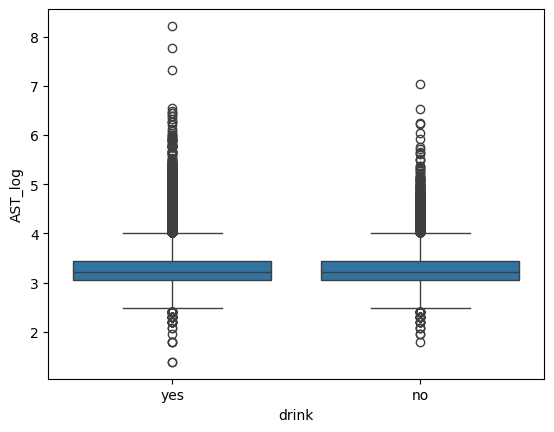

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.boxplot(x='drink', y='AST_log', data=health)
plt.show()

#### ALT

In [ ]:
health['ALT_log'] = np.log1p(health['ALT'])

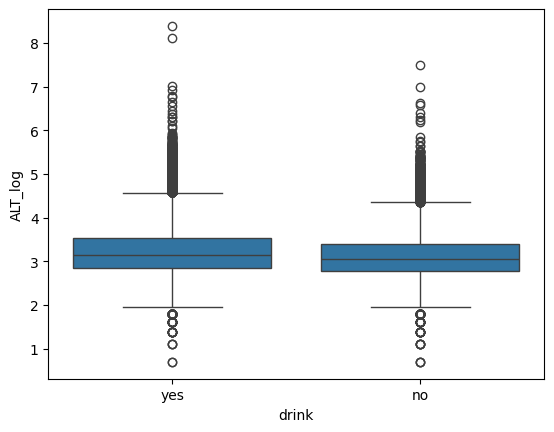

In [ ]:
plt.figure()

sns.boxplot(x='drink', y='ALT_log', data=health)
plt.show()

#### GGT

In [ ]:
health['GGT_log'] = np.log1p(health['GGT'])

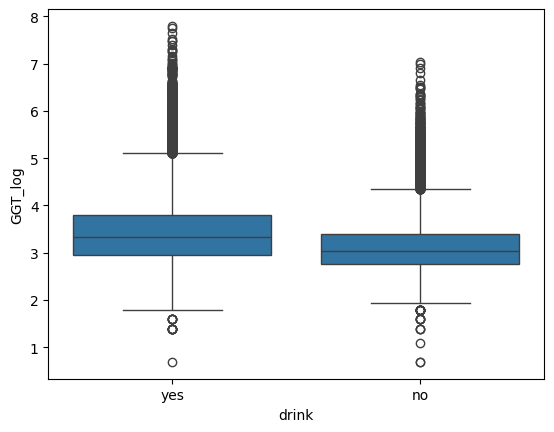

In [ ]:
plt.figure()

sns.boxplot(x='drink', y='GGT_log', data=health)
plt.show()

AST, ALT, GGT 모두 음주군의 값이 비음주군의 값보다 높게 나타났다. 특히 AST, GGT에서 두 집간 단 차이가 더욱 뚜렷하게 관찰되었다. AST는 간 이외 기타 장기의 영향도 받을 수 있는 반면, ALT와 GGT는 간 기능과 보다 밀접한 관련이 있어 음주의 영향이 상대적으로 명확하게 나타난 것으로 해석된다.

이러한 결과를 종합해 보면, 음주가 간 기능 이상과 충분한 연관성이 있음을 알 수 있다.

### 보조 변수 분석

#### 1. 흡연 여부

In [ ]:
from scipy.stats import f_oneway

con1 = health[health['smoke'] == 'never']['GGT']
con2 = health[health['smoke'] == 'former']['GGT']
con3 = health[health['smoke'] == 'current']['GGT']

f_oneway(con1, con2, con3)

F_onewayResult(statistic=np.float64(2249.0749727931343), pvalue=np.float64(0.0))

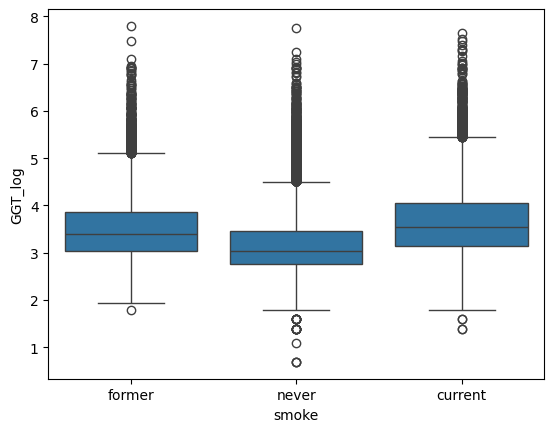

In [ ]:
plt.figure()
sns.boxplot(data=health, x='smoke', y='GGT_log')

plt.show()

일원분산분석(ANOVA) 결과, 흡연 상태 또한 따라 간 기능 지표의 평균에 통계적으로 매우 유의한 차이가 나타난다. 박스플롯을 보아서도 **흡연하지 않은 집단**과, **이전에 경험이 있거나 현재 하고 있는 집단과의 GGT 차이**가 눈에 띄게 나타난다. 이는 흡연 상태 또한 간 기능 지표와 관련될 수 있음을 시사한다.

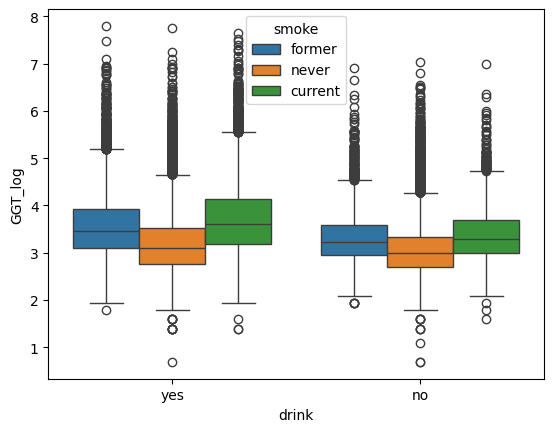

In [ ]:
plt.figure()

sns.boxplot(data=health, x='drink', y='GGT_log', hue='smoke')
plt.show()

전체적인 음주 여부, 흡연 여부와 GGT 수치를 비교해 볼 때도 음주 집단 내에 흡연자 집단의 박스플롯이 제일 GGT 수치가 높은 것으로 확인된다.
이는 음주, 흡연 상태가 간 기능 상태와 밀접한 연관을 가질 가능성이 있음을 나타낸다.

#### 2. 체질량지수(BMI)

먼저, bmi 수치를 편하게 분석하기 위해 데이터를 범주화한다.<br/>
세계보건기구의 기준을 참고하여 저체중(under), 정상(healthy), 비만(over), 고도비만(obese)로 분류하였다.

In [ ]:
bmi_max = health['bmi'].max() + 1

health['bmi'] = pd.cut(health['bmi'],
       bins=[0, 18.5, 23, 35, bmi_max],
       labels=['under', 'healthy', 'over', 'obese'],
       right=False)

In [ ]:
health['bmi'].unique()

['healthy', 'over', 'under', 'obese']
Categories (4, object): ['under' < 'healthy' < 'over' < 'obese']

각 bmi 범주에 따른 간 기능 수치 평균을 비교해 보았다.
BMI가 큰 그룹일수록 간 수치가 높아지는 것을 확인할 수 있다.

In [ ]:
bmi_analysis = health.groupby('bmi')[['AST', 'ALT', 'GGT']].mean()
print(bmi_analysis)

               AST        ALT        GGT
bmi                                     
under    25.213977  18.719949  26.313342
healthy  25.397303  21.799621  28.757009
over     28.517516  31.423852  40.979007
obese    38.125418  55.966555  56.806020


/tmp/ipython-input-491462555.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_analysis = health.groupby('bmi')[['AST', 'ALT', 'GGT']].mean()


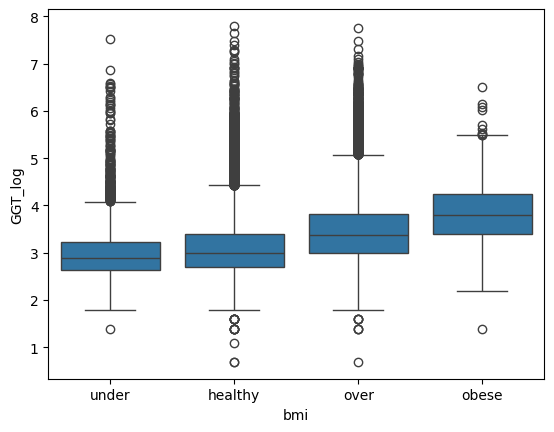

In [ ]:
plt.figure()
sns.boxplot(data=health, x='bmi', y='GGT_log')

plt.show()

이는 박스플롯을 통해 확인해 보면 더 극명히 나타난다. 고도비만으로 BMI 수치가 커질수록 GGT의 수치도 높아지는 것을 확인할 수 있다.<br/>
해당 결과는, bmi와 간 기능 수치가 연관성이 있음을 시사한다.

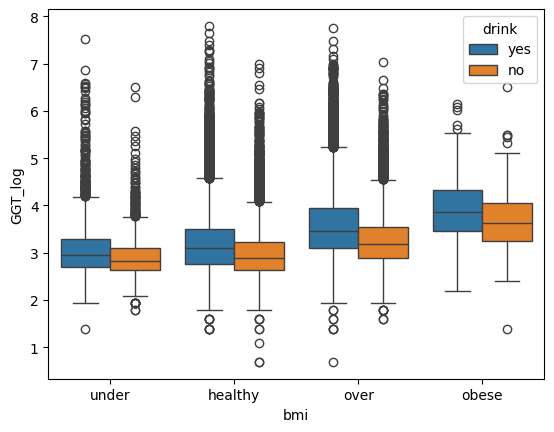

In [ ]:
plt.figure()
sns.boxplot(data=health, x='bmi', y='GGT_log', hue='drink')

plt.show()

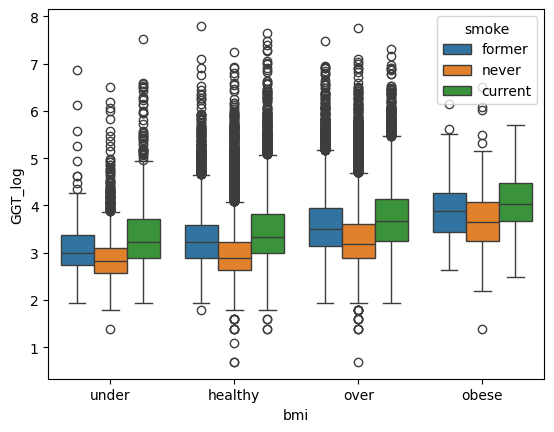

In [ ]:
plt.figure()
sns.boxplot(data=health, x='bmi', y='GGT_log', hue='smoke')

plt.show()

음주, 흡연 여부와 함께 보았을 때에도 고도비만이면서 흡연 혹은 음주를 즐기는 집단에게 간 수치가 더 높은 것을 확인할 수 있다.
연관성이 있으리라 생각헀던 보조 변수들도 간 수치에 영향을 줄 수 있음을 확인할 수 있었다.

### 결론

본 연구에서는 건강검진 데이터를 활용해 음주 여부에 따른 간 기능(AST, ALT, GGT)의 차이를 분석하였다. 결과적으로, 음주군은 비음주군에 비해 모든 간 기능 지표에서 더 높은 값을 보였으며 통계적으로도 매우 유의한 차이가 확인되었다. 특히 GGT에서 눈에 띄게 큰 차이가 나타나 음주와의 연관성이 뚜렷하게 관찰되었음을 알 수 있다.

또한, 보조 변수인 bmi와 흡연 여부 분석 결과 간 기능 지표와 유의한 관련을 보이는 것으로 나타났다. 이는 간 기능이 음주뿐 아닌 여러 생활습관의 영향을 함께 받을 수 있음을 시사한다. 생활습관을 건강하게 고친다면, 간 건강에 유의미한 변화를 확인할 수 있을 것으로 생각된다.

본 연구는 변수 간 인과관게를 직접적으로 확인하기에는 한계가 존재하나, 생활습관 요인이 간 기능과 밀접하게 연관될 수 있음을 보인다는 점에서 의의가 있다.